# **Assignment No - 9**

---

**Name**- Vaishnavi Krishnat Phalle.
**Roll No**-EN23107096.
**Class**-AIDS(B).
**Batch**- A.

---

**Title** -
Build an XGBoost classification model to predict loan defaults based on borrower information and loan characteristics. Preprocess the data by handling missing values, encoding categorical variables, and addressing class imbalance. Evaluate the model using AUC-ROC and F1 score. Dataset: Lending Club Loan Data (Kaggle)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('loan.csv')

/tmp/ipython-input-2733343264.py:1: DtypeWarning: Columns (19,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('loan.csv')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743100 entries, 0 to 743099
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 822.1+ MB


In [ ]:
df.shape

(743100, 145)

In [ ]:
df.isnull().sum()

,0
id,743100
member_id,743100
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
settlement_status,736319
settlement_date,736319
settlement_amount,736319
settlement_percentage,736319


In [ ]:
df = df.dropna(subset=['loan_status'])
df['loan_status'].isnull().sum()
df = df[df['loan_status'].notnull()]

df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x=='Default' else 0)
X = df.drop(['loan_status', 'emp_length'], axis=1)
y = df['loan_status']

In [ ]:
object_cols = df.select_dtypes(include='object').columns
print(object_cols)
drop_cols = ['emp_title', 'desc', 'zip_code', 'issue_d', 'earliest_cr_line',
             'last_pymnt_d', 'next_pymnt_d', 'sec_app_earliest_cr_line',
             'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
             'settlement_date']
df = df.drop(columns=drop_cols)
from sklearn.preprocessing import LabelEncoder

for col in ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
            'initial_list_status', 'application_type', 'hardship_flag',
            'debt_settlement_flag']:
    df[col] = df[col].astype(str)  # ensure all are strings
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
multi_cat_cols = ['purpose', 'title', 'hardship_type', 'hardship_reason', 'hardship_status',
                  'disbursement_method', 'settlement_status']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x=='Default' else 0)
print(df.dtypes.value_counts())


Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'pymnt_plan',
       'desc', 'purpose', 'title', 'zip_code', 'addr_state',
       'earliest_cr_line', 'initial_list_status', 'last_pymnt_d',
       'next_pymnt_d', 'last_credit_pull_d', 'application_type',
       'verification_status_joint', 'sec_app_earliest_cr_line',
       'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
       'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
       'hardship_loan_status', 'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date'],
      dtype='object')
float64    105
bool        36
int64       14
object       7
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
for col in X.select_dtypes(include='number'):
    X[col] = X[col].fillna(X[col].median())
for col in X.select_dtypes(include='object'):
    X[col] = X[col].fillna(X[col].mode()[0])
    X[col] = LabelEncoder().fit_transform(X[col])

In [ ]:
model = XGBClassifier(
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    use_label_encoder=False,
    eval_metric='logloss'
)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:35:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [ ]:
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("F1 Score:", f1_score(y_test, y_pred))

AUC-ROC: 0.7626785630176898
F1 Score: 0.0


In [ ]:
y_pred_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

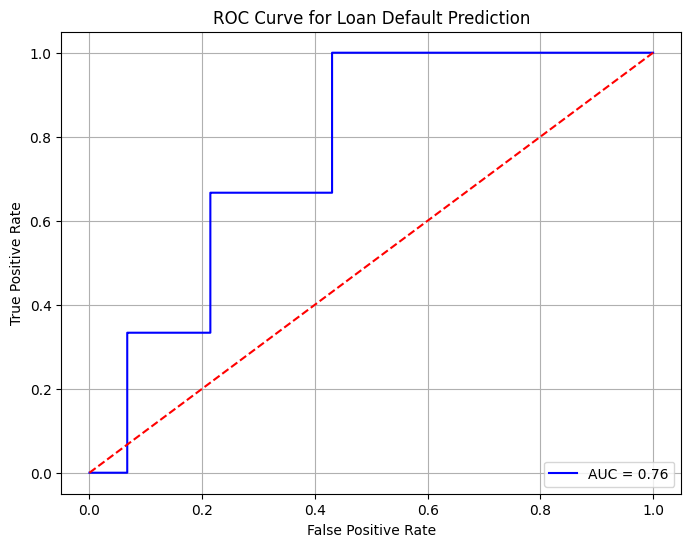

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_score:.2f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Default Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()